## Imports

This section loads the libraries used for training and evaluation.

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## Device

This section checks the available device.

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


## Dataset paths

This section defines the dataset folders.

In [30]:
data_dir = Path("../data/raw/fer2013")
train_dir = data_dir / "train"
test_dir = data_dir / "test"

print("Train path:", train_dir.resolve())
print("Test path:", test_dir.resolve())

Train path: C:\Users\harsh\facial-emotion-recognition-cv\data\raw\fer2013\train
Test path: C:\Users\harsh\facial-emotion-recognition-cv\data\raw\fer2013\test


## Transforms

This section prepares the training and test transforms.

In [31]:
image_size = (48, 48)
batch_size = 64

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

print("Image size:", image_size)
print("Batch size:", batch_size)

Image size: (48, 48)
Batch size: 64


## Dataset loading

This section loads the training and test datasets.

In [32]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

class_names = train_dataset.classes

print("Classes:", class_names)
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Training samples: 28709
Test samples: 7178


## Data loaders

This section creates the data loaders.

In [33]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 449
Test batches: 113


## Sample batch

This section checks a batch from the training loader.

In [34]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 1, 48, 48])
Label batch shape: torch.Size([64])


## Model

This section defines the custom CNN architecture.

In [35]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CustomCNN(num_classes=len(class_names)).to(device)
print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)


## Loss and optimizer

This section defines the training objective.

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss: CrossEntropyLoss()
Optimizer: Adam


## Training settings

This section sets the number of training epochs.

In [37]:
epochs = 15

checkpoint_dir = Path("../outputs/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

best_model_path = checkpoint_dir / "custom_cnn_aug_best.pth"

print("Epochs:", epochs)
print("Best model path:", best_model_path.resolve())

Epochs: 15
Best model path: C:\Users\harsh\facial-emotion-recognition-cv\outputs\checkpoints\custom_cnn_aug_best.pth


## Training loop

This section trains the model and saves the best checkpoint.

In [38]:
train_losses = []
train_accuracies = []

best_train_acc = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    if epoch_acc > best_train_acc:
        best_train_acc = epoch_acc
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

Epoch 01/15 | Train Loss: 1.6956 | Train Acc: 0.3151
Epoch 02/15 | Train Loss: 1.4849 | Train Acc: 0.4225
Epoch 03/15 | Train Loss: 1.3812 | Train Acc: 0.4720
Epoch 04/15 | Train Loss: 1.3240 | Train Acc: 0.4919
Epoch 05/15 | Train Loss: 1.2848 | Train Acc: 0.5098
Epoch 06/15 | Train Loss: 1.2586 | Train Acc: 0.5214
Epoch 07/15 | Train Loss: 1.2282 | Train Acc: 0.5344
Epoch 08/15 | Train Loss: 1.2071 | Train Acc: 0.5431
Epoch 09/15 | Train Loss: 1.1883 | Train Acc: 0.5481
Epoch 10/15 | Train Loss: 1.1776 | Train Acc: 0.5560
Epoch 11/15 | Train Loss: 1.1634 | Train Acc: 0.5622
Epoch 12/15 | Train Loss: 1.1500 | Train Acc: 0.5647
Epoch 13/15 | Train Loss: 1.1407 | Train Acc: 0.5693
Epoch 14/15 | Train Loss: 1.1370 | Train Acc: 0.5688
Epoch 15/15 | Train Loss: 1.1218 | Train Acc: 0.5761


## Training history

This section shows the training loss.

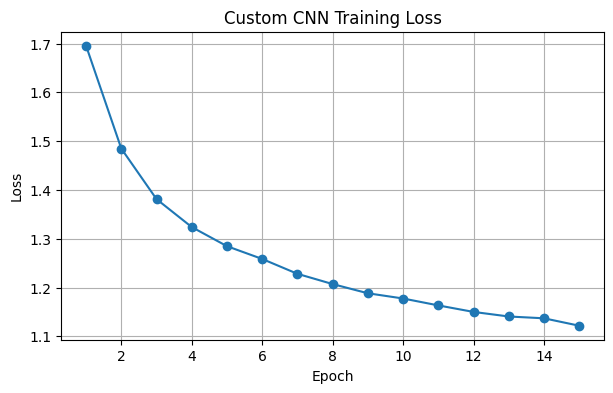

In [39]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Training Loss")
plt.grid(True)
plt.show()

## Training accuracy

This section shows the accuracy trend during training.

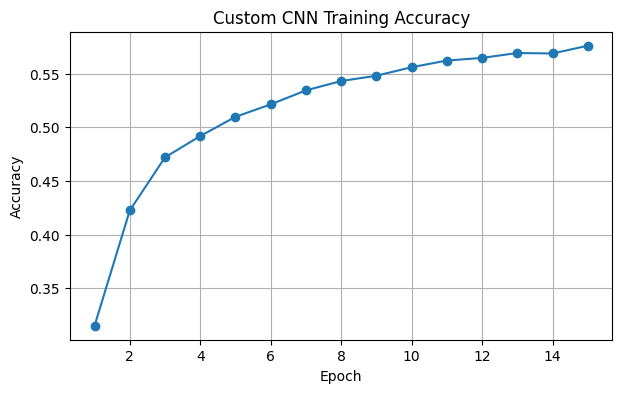

In [40]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Training Accuracy")
plt.grid(True)
plt.show()

## Best checkpoint load

This section loads the saved best model.

In [41]:
best_model = CustomCNN(num_classes=len(class_names)).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model.eval()

print("Best model loaded")

Best model loaded


C:\Users\harsh\AppData\Local\Temp\ipykernel_25192\2756459735.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(best_model_path, map_l

## Test evaluation

This section evaluates the trained model on the test set.

In [42]:
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.5814


In [43]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Classification Report:

              precision    recall  f1-score   support

       angry     0.4862    0.5167    0.5010       958
     disgust     0.6667    0.1441    0.2370       111
        fear     0.4379    0.2617    0.3276      1024
       happy     0.8078    0.8033    0.8055      1774
     neutral     0.5301    0.5288    0.5294      1233
         sad     0.4164    0.5830    0.4858      1247
    surprise     0.7526    0.7100    0.7307       831

    accuracy                         0.5814      7178
   macro avg     0.5854    0.5068    0.5167      7178
weighted avg     0.5878    0.5814    0.5763      7178



## Confusion matrix

This section shows the class-wise test results.

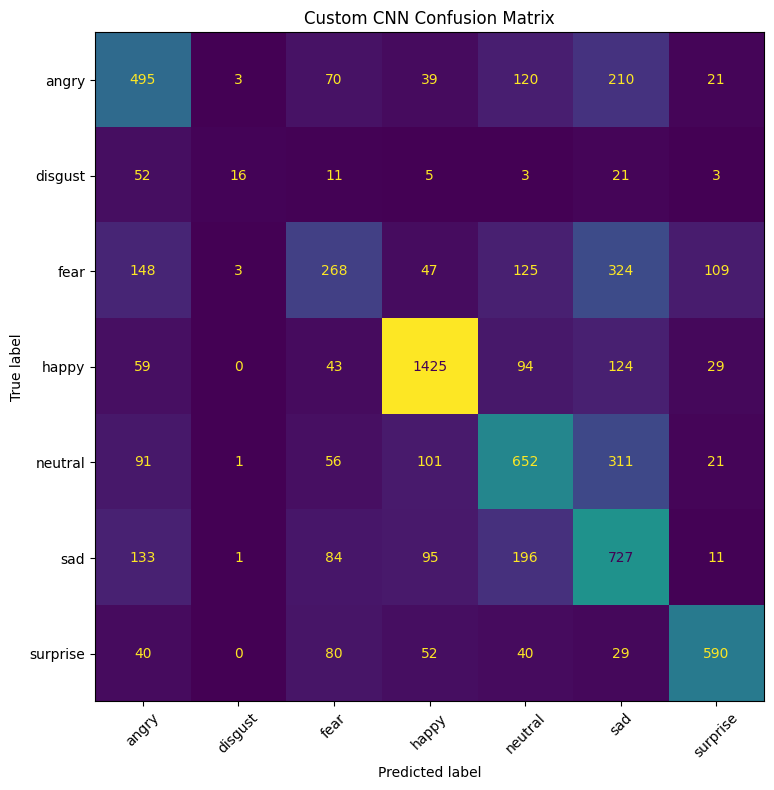

In [45]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Custom CNN Confusion Matrix")
plt.tight_layout()
plt.show()

## Sample predictions

This section displays a few predictions from the test set.

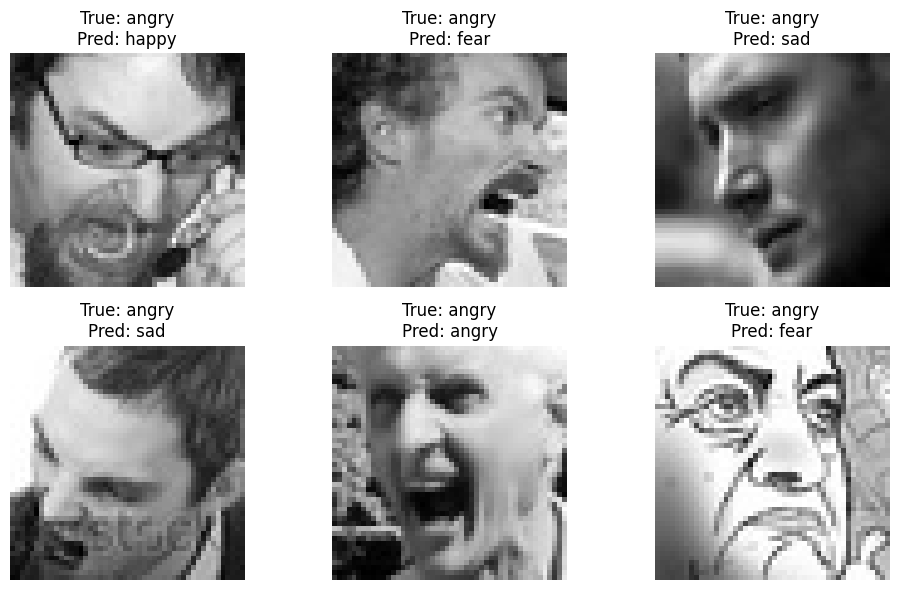

In [46]:
sample_images = []
sample_true = []
sample_pred = []

for i in range(6):
    image, label = test_dataset[i]
    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = best_model(image_input)
        pred = torch.argmax(output, dim=1).item()

    sample_images.append(image.squeeze().numpy())
    sample_true.append(class_names[label])
    sample_pred.append(class_names[pred])

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i], cmap="gray")
    plt.title(f"True: {sample_true[i]}\nPred: {sample_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observation

The custom CNN model shows a clear improvement over both LBP and HOG baselines, achieving higher accuracy and better class-wise performance. The training curves indicate stable learning, with loss decreasing and accuracy increasing consistently across epochs. The model performs particularly well for classes such as happy and surprise, while performance is moderate for neutral and angry, and lower for fear and disgust. The confusion matrix shows improved class separation, although some confusion remains between visually similar expressions such as fear, sad, and neutral.

## Report note

A custom convolutional neural network is used to learn hierarchical feature representations directly from facial images. Compared to traditional methods, the CNN achieves significantly better performance by capturing spatial and structural patterns in the data. While the model demonstrates improved generalisation, challenges remain in distinguishing subtle and underrepresented classes, highlighting the impact of dataset imbalance and the need for further optimisation or advanced architectures.